# EDA & Baseline Model
**Objective:** To clean the raw dataset, perform Exploratory Data Analysis (EDA) to understand the factors influencing UAE car prices, and establish a baseline prediction model using Linear Regression.

## 1. Environment Setup & Library Imports
In this section, we import the necessary libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. Loading the Raw Data
We begin by loading the raw dataset: `uae_used_cars_10k.csv`. We will inspect the first few rows, review the data types, and check for missing values to inform our cleaning strategy.

In [20]:
df = pd.read_csv("../data/uae_used_cars_10k.csv")

print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- First 5 Rows ---


,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Color,Location,Description
0,toyota,camry,2016,47819,156500,Sedan,4,Automatic Transmission,Gasoline,Black,Dubai,"2016 toyota camry with Rear camera, Leather se..."
1,kia,sorento,2013,61250,169543,SUV,4,Automatic Transmission,Gasoline,Grey,Abu Dhabi,"2013 kia sorento with Sunroof, Adaptive cruise..."
2,mini,cooper,2023,31861,221583,Soft Top Convertible,4,Automatic Transmission,Gasoline,Grey,Dubai,"2023 mini cooper with Adaptive cruise control,..."
3,nissan,altima,2016,110322,69754,Sedan,4,Automatic Transmission,Gasoline,Red,Dubai,"2016 nissan altima with Rear camera, Adaptive ..."
4,toyota,land-cruiser-76-series,2020,139994,71399,Pick Up Truck,4,Manual Transmission,Gasoline,White,Dubai,2020 toyota land-cruiser-76-series with Adapti...



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Make          10000 non-null  object
 1   Model         10000 non-null  object
 2   Year          10000 non-null  int64 
 3   Price         10000 non-null  int64 
 4   Mileage       10000 non-null  int64 
 5   Body Type     10000 non-null  object
 6   Cylinders     9895 non-null   object
 7   Transmission  10000 non-null  object
 8   Fuel Type     10000 non-null  object
 9   Color         10000 non-null  object
 10  Location      10000 non-null  object
 11  Description   10000 non-null  object
dtypes: int64(3), object(9)
memory usage: 937.6+ KB

--- Summary Statistics ---


,Year,Price,Mileage
count,10000.000000,1.000000e+04,10000.000000
mean,2014.472800,2.452345e+05,155161.871700
std,5.790839,4.709773e+05,83681.858983
min,2005.000000,7.183000e+03,10006.000000
25%,2009.000000,5.035250e+04,82904.000000
50%,2014.000000,1.027660e+05,154370.500000
75%,2019.000000,2.312480e+05,227551.250000
max,2024.000000,1.468698e+07,299996.000000



--- Missing Values ---
Make              0
Model             0
Year              0
Price             0
Mileage           0
Body Type         0
Cylinders       105
Transmission      0
Fuel Type         0
Color             0
Location          0
Description       0
dtype: int64


## 3. Exploratory Data Analysis (EDA)
Before cleaning the data, we visualize the distributions and relationships to identify outliers. We will look specifically at:
1. The distribution of car prices across the dataset.
2. The relationship between mileage and price.
3. The average pricing among the top 10 most common car makes.

Text(0.5, 1.0, 'Price by Top 10 Makes')

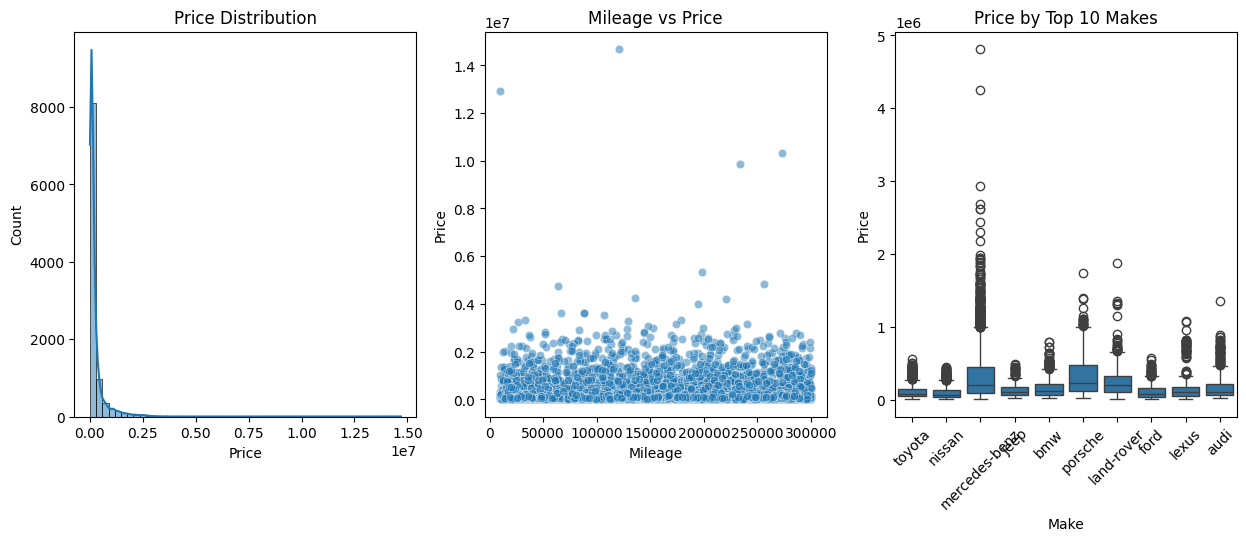

In [7]:

plt.figure(figsize=(15, 5))

# 1. Price Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution')

# 2. Mileage vs Price
plt.subplot(1, 3, 2)
sns.scatterplot(x='Mileage', y='Price', data=df, alpha=0.5)
plt.title('Mileage vs Price')

# 3. Top 10 Makes by Price
plt.subplot(1, 3, 3)
top_makes = df['Make'].value_counts().nlargest(10).index
sns.boxplot(x='Make', y='Price', data=df[df['Make'].isin(top_makes)])
plt.xticks(rotation=45)
plt.title('Price by Top 10 Makes')

## 4. Data Cleaning
We need to handle missing values and remove extreme outliers that could skew our model. We will do this by:
* Dropping any rows missing critical information (Price, Make, Model, Year).
* Dropping unnecessary columns (unstructured text or unneeded features)
* Filling the missing 'Cylinders' values with the most frequent value.
* Restricting our analysis to cars priced between AED 5,000 and AED 500,000.
* Capping the mileage at 500,000 km.

In [21]:
# Force numeric columns to actually be numeric (turns text like 'Unknown' into NaN)
# Then we drop those NaNs
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Cylinders'] = pd.to_numeric(df['Cylinders'], errors='coerce')

# Drop rows where critical columns are missing
df = df.dropna(subset=['Price', 'Make', 'Model', 'Year'])

# Drop unnecessary columns (unstructured text or unneeded features)
columns_to_drop = ['Description', 'Color']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Fill missing cylinders with the most frequent value
df['Cylinders'] = df['Cylinders'].fillna(df['Cylinders'].mode()[0])

# Remove outliers based on project parameters
df_clean = df[(df['Price'] >= 5000) & (df['Price'] <= 500000)].copy()
df_clean = df_clean[df_clean['Mileage'] <= 500000]

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")

Rows before cleaning: 10000
Rows after cleaning: 8896


In [16]:
df_clean.head()

,Make,Model,Year,Price,Mileage,Body Type,Cylinders,Transmission,Fuel Type,Location
0,toyota,camry,2016,47819,156500,Sedan,4,Automatic Transmission,Gasoline,Dubai
1,kia,sorento,2013,61250,169543,SUV,4,Automatic Transmission,Gasoline,Abu Dhabi
2,mini,cooper,2023,31861,221583,Soft Top Convertible,4,Automatic Transmission,Gasoline,Dubai
3,nissan,altima,2016,110322,69754,Sedan,4,Automatic Transmission,Gasoline,Dubai
4,toyota,land-cruiser-76-series,2020,139994,71399,Pick Up Truck,4,Manual Transmission,Gasoline,Dubai


## 5. Feature Engineering & Dataset Export
Machine learning models require numerical input. We will calculate the `car_age` and use One-Hot Encoding to convert categorical variables (like Make, Model, and City) into a format our models can understand.

Finally, we will export this cleaned and encoded dataset as `uae_cars_cleaned.csv` so the team can use it for their respective models.

In [22]:
# Fetch the current year
current_year = datetime.now().year

# Create Car Age feature 
df_clean['car_age'] = current_year - df_clean['Year']

# Select features for encoding
categorical_cols = ['Make', 'Model', 'Location', 'Transmission', 'Fuel Type', 'Body Type']

# Only encode if these columns exist in the specific CSV
cols_to_encode = [col for col in categorical_cols if col in df_clean.columns]

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cols_to_encode, drop_first=True)

# Export the final dataset for the team
df_encoded.to_csv("../data/uae_cars_cleaned.csv", index=False)
print("Cleaned and encoded dataset saved to '../data/uae_cars_cleaned.csv'")

Cleaned and encoded dataset saved to '../data/uae_cars_cleaned.csv'


## 6. Train/Validation/Test Split
We will split the data as follows: 
* **70% Training** (To train the model)
* **15% Validation** (To tune hyperparameters later)
* **15% Testing** (To evaluate final performance)

In [23]:
# Separate features (X) and target (y)
X = df_encoded.drop(['Price'], axis=1)
y = df_encoded['Price']

# First split: 70% Train, 30% Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second split: Split the 30% equally into 15% Val and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Train set: (6227, 548)
Validation set: (1334, 548)
Test set: (1335, 548)


## 7. Baseline Model: Linear Regression
We will train a standard Linear Regression model to establish a baseline. All subsequent models built by the team (Random Forest, XGBoost, etc.) must beat this baseline performance.

We will evaluate the model using:
* **RMSE (Root Mean Squared Error):** The average error in AED.
* **MAE (Mean Absolute Error):** The absolute average error in AED.
* **R^2 Score:** The proportion of variance in the price that our model explains.

In [24]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on Train, Validation, and Test sets
y_pred_train = lr_model.predict(X_train)
y_pred_val = lr_model.predict(X_val)
y_pred_test = lr_model.predict(X_test)

# Function to calculate metrics
def evaluate_model(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {set_name} Performance ---")
    print(f"RMSE: AED {rmse:,.2f}")
    print(f"MAE:  AED {mae:,.2f}")
    print(f"R^2:   {r2:.4f}\n")

evaluate_model(y_train, y_pred_train, "Training Set")
evaluate_model(y_val, y_pred_val, "Validation Set")
evaluate_model(y_test, y_pred_test, "Test Set")

--- Training Set Performance ---
RMSE: AED 73,101.05
MAE:  AED 50,548.05
R^2:   0.5410

--- Validation Set Performance ---
RMSE: AED 76,184.03
MAE:  AED 53,901.15
R^2:   0.4978

--- Test Set Performance ---
RMSE: AED 76,811.84
MAE:  AED 53,418.28
R^2:   0.4727



## 8. Model Visual Evaluation
Finally, we visualize our model's performance by plotting the actual test prices against our predicted prices, and analyzing the distribution of the residual errors.

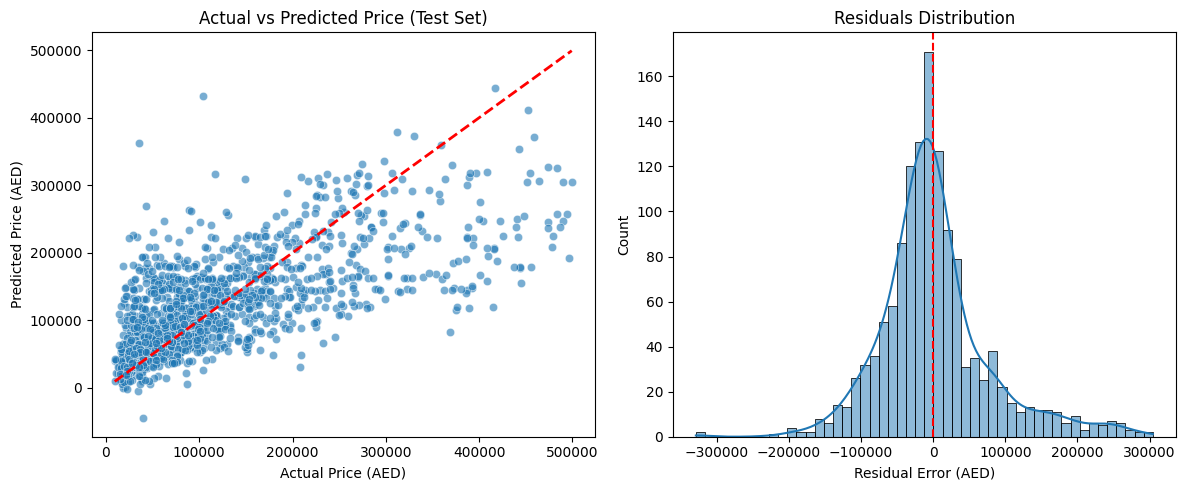

In [25]:
plt.figure(figsize=(12, 5))

# Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title('Actual vs Predicted Price (Test Set)')

# Residuals Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_test
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Residual Error (AED)')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()